### Simple Neural Networks in python using Tensorflow

In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# steps before Creating a Neural Network (preprocess the Data)

In [5]:
%%time
# remove warnings 
import warnings
warnings.filterwarnings('ignore')


# load Titaninc dataset 
titanic = sns.load_dataset('titanic')


# preprocessing
# droping rows with missing 'age' and 'embarked' values 
titanic.dropna(subset=['age', 'embarked'], inplace=True)

# converting categorical variables to dummy variables
titanic = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who', 'deck'], drop_first=True)

# selecting feature and target
X = titanic.drop(['survived', 'alive', 'embark_town', 'adult_male', 'alone'], axis=1)
y = titanic['survived']

# spliting the dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# standardizing the data 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Building the model 
input_layer = tf.keras.layers.Dense(10, activation='relu', input_shape=(X_train.shape[1],)) # input layer
# hidden_layer = tf.keras.layers.Dense(10, activation='relu') # hidden layer
output_layer = tf.keras.layers.Dense(1, activation='sigmoid') # output layer

# combine the layers
model = tf.keras.Sequential([input_layer, output_layer])

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_data=(X_test, y_test))
# evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)



Epoch 1/100
18/18 [==============================] - 3s 47ms/step - loss: 0.8237 - accuracy: 0.4464 - val_loss: 0.8008 - val_accuracy: 0.5035
Epoch 2/100
18/18 [==============================] - 0s 16ms/step - loss: 0.7607 - accuracy: 0.5589 - val_loss: 0.7354 - val_accuracy: 0.6154
Epoch 3/100
18/18 [==============================] - 0s 18ms/step - loss: 0.7054 - accuracy: 0.6046 - val_loss: 0.6839 - val_accuracy: 0.6224
Epoch 4/100
18/18 [==============================] - 0s 15ms/step - loss: 0.6594 - accuracy: 0.6485 - val_loss: 0.6424 - val_accuracy: 0.6573
Epoch 5/100
18/18 [==============================] - 0s 16ms/step - loss: 0.6194 - accuracy: 0.6942 - val_loss: 0.6073 - val_accuracy: 0.6923
Epoch 6/100
18/18 [==============================] - 0s 18ms/step - loss: 0.5844 - accuracy: 0.7206 - val_loss: 0.5768 - val_accuracy: 0.7133
Epoch 7/100
18/18 [==============================] - 0s 15ms/step - loss: 0.5532 - accuracy: 0.7504 - val_loss: 0.5525 - val_accuracy: 0.7413
Epoch 

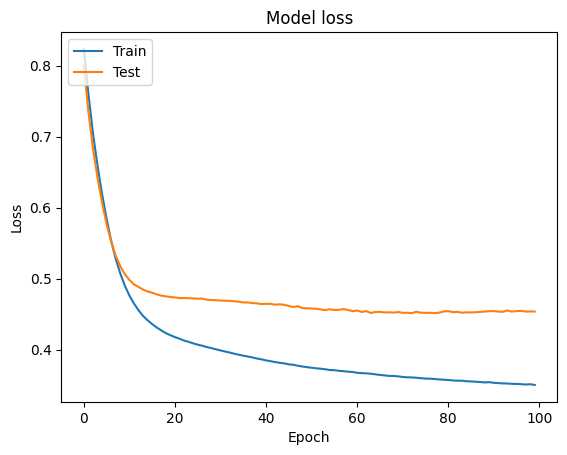

In [6]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()



In [ ]:
# evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

Test Accuracy: 0.8041958212852478
Test Loss: 0.5133159756660461


In [7]:
import sys

import tensorflow.keras
import pandas as pd
import sklearn as sk
import scipy as sp
import tensorflow as tf
import platform

print(f"Python Platform: {platform.platform()}")
print(f"Tensor Flow Version: {tf.__version__}")
print()
print(f"Python {sys.version}")
print(f"Pandas {pd.__version__}")
print(f"Scikit-Learn {sk.__version__}")
print(f"SciPy {sp.__version__}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "NOT AVAILABLE")


Python Platform: Windows-10-10.0.26100-SP0
Tensor Flow Version: 2.10.0

Python 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Pandas 2.3.3
Scikit-Learn 1.7.2
SciPy 1.15.3
GPU is available


In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
